In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest


# 1. Load the dataset
df = pd.read_csv("C:/Users/gary4/Documents/GitHub Project Data Files/Procurement and payroll fraud/procurement.csv")
print(df.head())

print(f"Dataset Shape: {df.shape}")
print("---")
print(df.info())

  procurement_id employee_id vendor_id  price_system  price_actual  \
0          P4000     EMP1133      V206       6787749       6787749   
1          P4001     EMP1009      V202       2661793        156344   
2          P4002     EMP1004      V209       7576651       7576651   
3          P4003     EMP1137      V209       7867218       7867218   
4          P4004     EMP1129      V218       8466027       8466027   

   price_difference  account_mismatch_flag  fraud_flag  fraud_probability  
0                 0                      0           0                NaN  
1           2505449                      1           1                NaN  
2                 0                      0           0                NaN  
3                 0                      0           0                NaN  
4                 0                      0           0                NaN  
Dataset Shape: (278, 9)
---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278 entries, 0 to 277
Data columns (total 9 c

In [3]:
#save the fraud flag for later drop others
ground_truth = df['fraud_flag']
df_unsupervised = df.drop(columns=['account_mismatch_flag','fraud_flag','fraud_probability'])

#feature engineer price variance percent
df_unsupervised['price_variance_pct'] = (df_unsupervised['price_difference']/ df_unsupervised['price_system'].replace(0, np.nan)).fillna(0)

#feature engineer deviation from vendors median price
vendor_medians = df_unsupervised.groupby('vendor_id')['price_actual'].transform('median')
df_unsupervised['vendor_deviation'] = df_unsupervised['price_actual']- vendor_medians

#feature engineer tranaction frequency between emplyee and vendor
df_unsupervised['emp_vendor_density'] = df_unsupervised.groupby(['employee_id', 'vendor_id'])['procurement_id'].transform('count')

#select features for the model
features_to_train = ['price_actual', 'price_difference', 'price_variance_pct', 'vendor_deviation', 'emp_vendor_density']

X = df_unsupervised[features_to_train]

print("Features ready for Isolation forest")
print(X.head(20))


Features ready for Isolation forest
    price_actual  price_difference  price_variance_pct  vendor_deviation  \
0        6787749                 0            0.000000               0.0   
1         156344           2505449            0.941264        -5431222.0   
2        7576651                 0            0.000000         2570109.0   
3        7867218                 0            0.000000         2860676.0   
4        8466027                 0            0.000000         3272967.0   
5        5987696                 0            0.000000               0.0   
6        1428988                 0            0.000000        -2985878.0   
7        5084752                 0            0.000000         2344752.0   
8        5374857                 0            0.000000          941475.0   
9        3977590                 0            0.000000         -455792.0   
10       7141651           1457949            0.169537          912301.5   
11       7610734                 0            0.0000

In [4]:
#initialise the forest
#using fixed random state so that results are reproducable
iso_forest = IsolationForest(contamination=0.01, random_state=42)

#fit the model -1 for anomolies, 1 for normal
df_unsupervised['anomaly_prediction'] = iso_forest.fit_predict(X)

#extract raw anomaly score
df_unsupervised['anomaly_score'] = iso_forest.decision_function(X)

#filter the flagged anomalies for investigation
anomalies = df_unsupervised[df_unsupervised['anomaly_prediction'] == -1]

print(f"Total transactions analysed: {len(df_unsupervised)}")
print(f"Number of anomalies flagged for NHSCFA review: {len(anomalies)}")

Total transactions analysed: 278
Number of anomalies flagged for NHSCFA review: 3


In [5]:
#print anomalies
print(anomalies)

    procurement_id employee_id vendor_id  price_system  price_actual  \
21           P4021     EMP1077      V224       3202575        285076   
217          P4217     EMP1158      V216       5660106      10934026   
225          P4225     EMP1123      V202       3882848       8520214   

     price_difference  price_variance_pct  vendor_deviation  \
21            2917499            0.910985        -7561116.0   
217           5273920            0.931771         5377903.0   
225           4637366            1.194321         2932648.0   

     emp_vendor_density  anomaly_prediction  anomaly_score  
21                    2                  -1      -0.039962  
217                   1                  -1      -0.077195  
225                   1                  -1      -0.075592  


In [6]:
#use the fraud flag to test how well the model did
#model: -1 = anomaly, 1 = normal
#flag: 1 = fraud, 0 = normal

df_unsupervised['mapped_prediction']=df_unsupervised['anomaly_prediction'].apply(lambda x: 1 if x == -1 else 0)

print("--- Confusion Matrix ---")
print(confusion_matrix(ground_truth, df_unsupervised['mapped_prediction']))

print("--- Calssification Report ---")
print(classification_report(ground_truth, df_unsupervised['mapped_prediction']))

--- Confusion Matrix ---
[[191   0]
 [ 84   3]]
--- Calssification Report ---
              precision    recall  f1-score   support

           0       0.69      1.00      0.82       191
           1       1.00      0.03      0.07        87

    accuracy                           0.70       278
   macro avg       0.85      0.52      0.44       278
weighted avg       0.79      0.70      0.58       278



In [14]:
#rerun the isolation forest to catch more fraud cases, increasing the contamination

iso_forest_tuned = IsolationForest(contamination=0.10, random_state=42)
df_unsupervised['tuned_prediction'] = iso_forest_tuned.fit_predict(X)
df_unsupervised['mapped_tuned_pred'] = df_unsupervised['tuned_prediction'].apply(lambda x: 1 if x== -1 else 0 )

print("--- Updated Confusion Matrix (10% contamination) ---")
print(confusion_matrix(ground_truth, df_unsupervised['mapped_tuned_pred']))

print("--- Updated classification report ----")
print(classification_report(ground_truth, df_unsupervised['mapped_tuned_pred']))


--- Updated Confusion Matrix (10% contamination) ---
[[191   0]
 [ 59  28]]
--- Updated classification report ----
              precision    recall  f1-score   support

           0       0.76      1.00      0.87       191
           1       1.00      0.32      0.49        87

    accuracy                           0.79       278
   macro avg       0.88      0.66      0.68       278
weighted avg       0.84      0.79      0.75       278



In [12]:
#Layer in K-Means to profile the entire feature set into behavioral groups
# Create 3 distinct clusters of procurement behavior


kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_unsupervised['behaviour_cluster'] = kmeans.fit_predict(X)

print("\n--- Breakdown of Fraud flags accross 3 behaviour clusters ---")
# This shows us which clusters hold the highest concentration of actual fraud
print(pd.crosstab(df_unsupervised['behaviour_cluster'], ground_truth))



--- Breakdown of Fraud flags accross 3 behaviour clusters ---
fraud_flag          0   1
behaviour_cluster        
0                  46  26
1                  74  24
2                  71  37


In [13]:
# Group by the behaviour cluster and calculate the average for each featur
cluster_profiles = df_unsupervised.groupby('behaviour_cluster')[features_to_train].mean()

print("--- Cluster Behavioural Profiles (Averages) ---")
print(cluster_profiles.round(2))

--- Cluster Behavioural Profiles (Averages) ---
                   price_actual  price_difference  price_variance_pct  \
behaviour_cluster                                                       
0                    1766522.81         550626.79                0.21   
1                    8188510.33         479174.54                0.07   
2                    4690449.63         389832.28                0.07   

                   vendor_deviation  emp_vendor_density  
behaviour_cluster                                        
0                       -3459994.16                1.12  
1                        2987870.32                1.08  
2                        -266387.76                1.34  


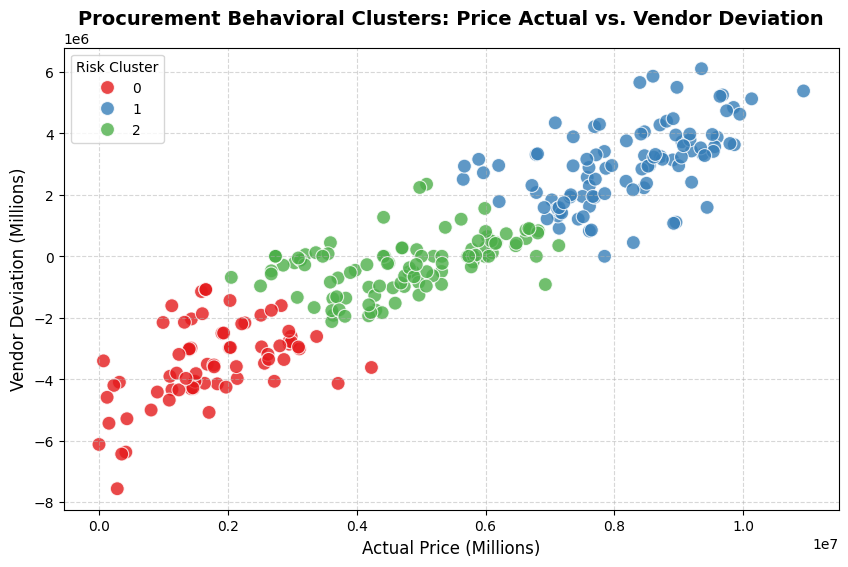

In [15]:
plt.figure(figsize=(10, 6))

# Create the scatter plot
sns.scatterplot(
    data=df_unsupervised,
    x='price_actual',
    y='vendor_deviation',
    hue='behaviour_cluster',
    palette='Set1',
    alpha=0.8,
    s=100
)

# Format the plot to look clean and professional
plt.title('Procurement Behavioral Clusters: Price Actual vs. Vendor Deviation', fontsize=14, fontweight='bold')
plt.xlabel('Actual Price (Millions)', fontsize=12)
plt.ylabel('Vendor Deviation (Millions)', fontsize=12)
plt.legend(title='Risk Cluster')
plt.grid(True, linestyle='--', alpha=0.5)

# Save it to your repository folder so you can display it in your README
plt.savefig('procurement_clusters.png', bbox_inches='tight', dpi=300)
plt.show()

In [21]:
#Isolate only the transactions flagged as anomalies by our tuned model
investigation_backlog = df_unsupervised[df_unsupervised['mapped_prediction'] == 1].copy()

#map the numeric clusters to the human-readable risk topologies
cluster_map = {
    0: 'Type A: Systemic Price Variance',
    1: 'Type B: High-Value Macro Price Escalation',
    2: 'Type C: High-Value Internal Relationship Density'
}

investigation_backlog['risk_typology'] = investigation_backlog['behaviour_cluster'].map(cluster_map)

#bring back the original ids and critical audit columns
report_columns = [
    'procurement_id', 'employee_id', 'vendor_id', 
    'price_actual', 'price_difference', 'price_variance_pct', 
    'vendor_deviation', 'emp_vendor_density', 'risk_typology', 'anomaly_score'
]

final_report = investigation_backlog[report_columns]

#Sort by the raw anomaly score
final_report = final_report.sort_values(by='anomaly_score', ascending = True)

#export a clean csv
final_report.to_csv('high_risk_procurement_alerts.csv', index = False)

print(f"📊 Success! Exported {len(final_report)} high-risk anomalies to 'high_risk_procurement_alerts.csv'.")

📊 Success! Exported 3 high-risk anomalies to 'high_risk_procurement_alerts.csv'.
